In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\project_DS\Predicting Insurance Costs\insurance.csv")

df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [10]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


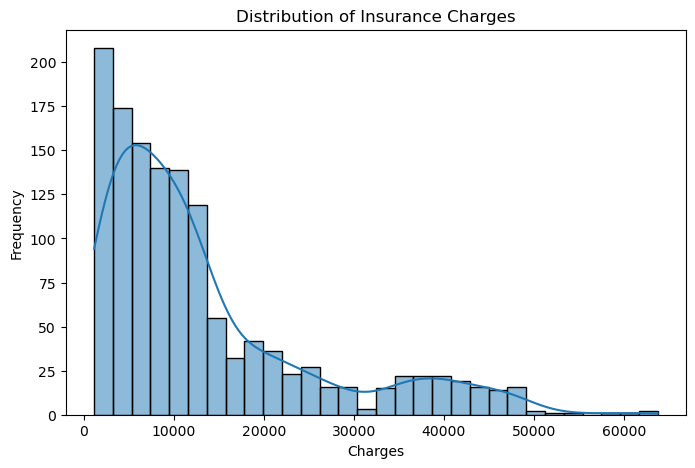

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df['charges'], kde=True)

plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

plt.show()

Age appears to have a positive relationship with insurance charges, but age alone does not fully explain the variation in charges.

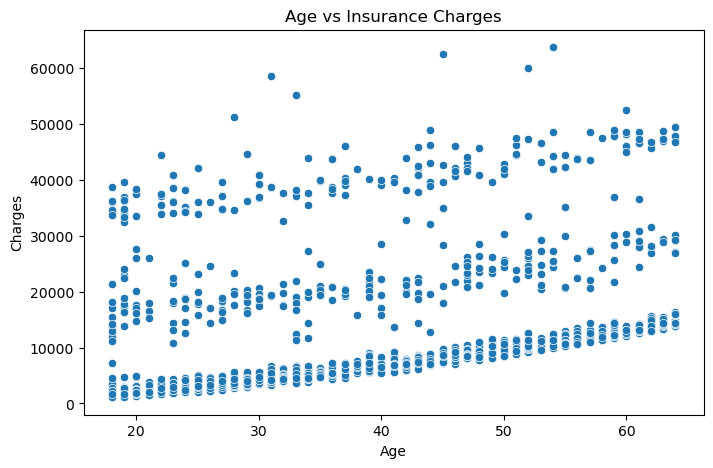

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='age', y='charges')

plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges')

plt.show()

BMI shows a positive but relatively scattered relationship with insurance charges, suggesting that BMI alone does not fully explain the variation in charges.

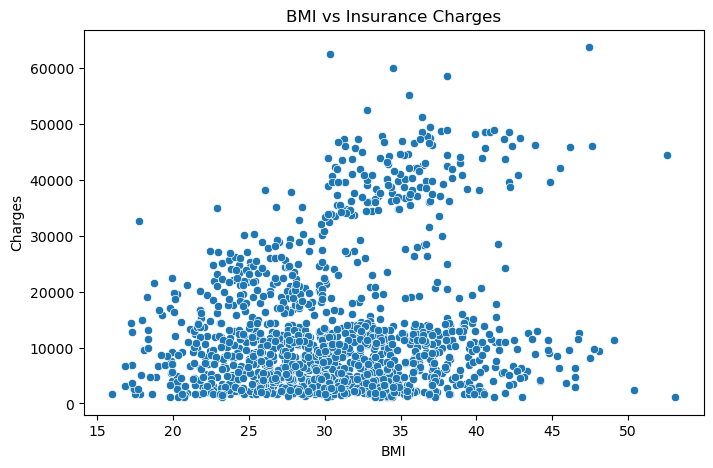

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='bmi', y='charges')

plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.show()

The number of children does not show a clear relationship with insurance charges. The charges vary widely within each children category.

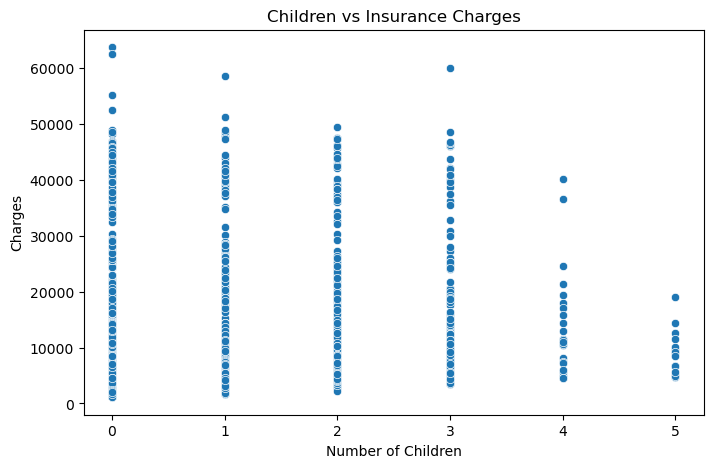

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='children', y='charges')

plt.title('Children vs Insurance Charges')
plt.xlabel('Number of Children')
plt.ylabel('Charges')

plt.show()

Smoking status is strongly associated with insurance charges and is likely to be an important predictor of the target variable.


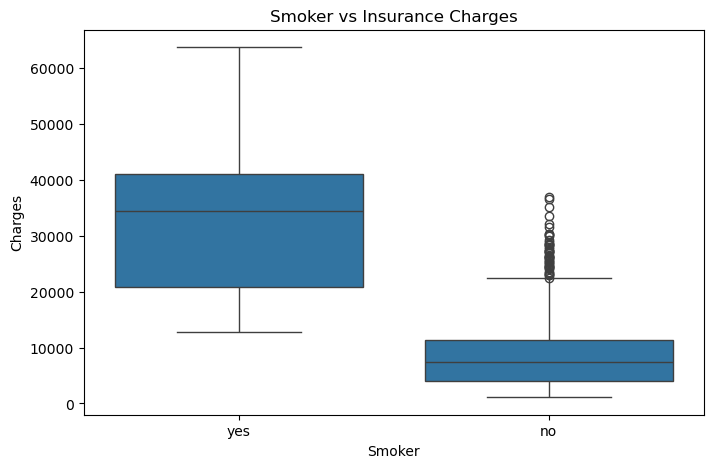

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='smoker', y='charges')

plt.title('Smoker vs Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')

plt.show()

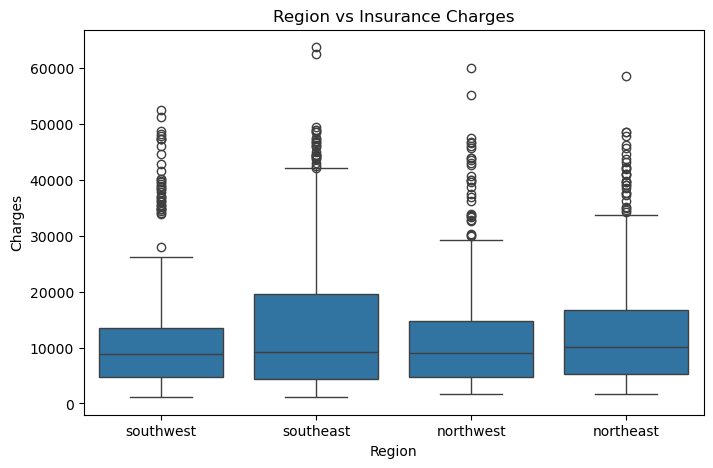

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='region', y='charges')

plt.title('Region vs Insurance Charges')
plt.xlabel('Region')
plt.ylabel('Charges')

plt.show()

In [18]:
correlation = df[['age', 'bmi', 'children', 'charges']].corr()

print(correlation)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


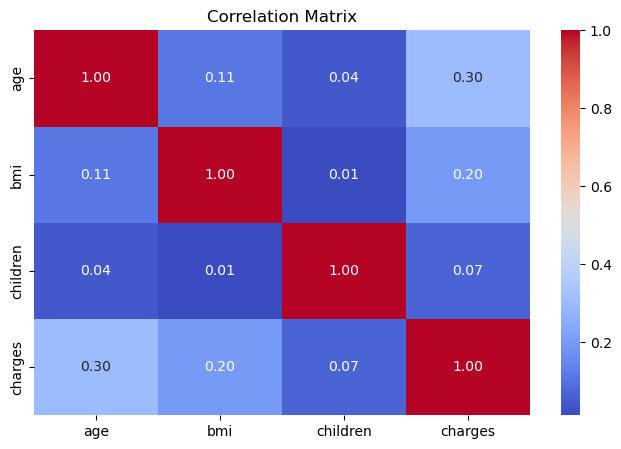

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')

plt.show()

In [22]:
x = df.drop('charges', axis=1)
y = df['charges']

print("Features:")
print(x.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

Target:
charges


In [23]:
x_encoded = pd.get_dummies(
    x,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

print(x_encoded.head())
print("\nShape:", x_encoded.shape)

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Shape: (1338, 8)


In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y, test_size=0.2, random_state=42)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1070, 8)
x_test: (268, 8)
y_train: (1070,)
y_test: (268,)


In [28]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Model trained successfully.")


Model trained successfully.


In [29]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

MSE: 33596915.85136146
R² Score: 0.7835929767120723


In [30]:
rmse = np.sqrt(mse)

residuals = y_test - y_pred

print("RMSE:", rmse)
print("Mean Residual:", residuals.mean())

RMSE: 5796.2846592762735
Mean Residual: -219.24066962508326


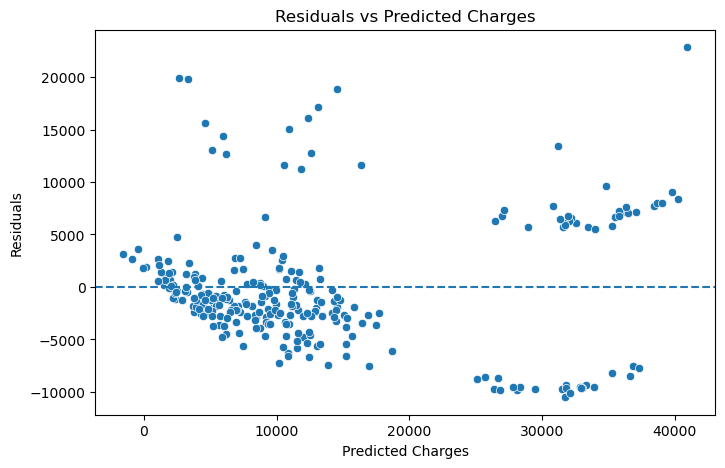

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, linestyle='--')

plt.title('Residuals vs Predicted Charges')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')

plt.show()

In [33]:
# Log transform the target
y_train_log = np.log(y_train)

# Build and train the model
log_model = LinearRegression()
log_model.fit(x_train, y_train_log)

# Predict log charges
y_pred_log = log_model.predict(x_test)

# Convert predictions back to original charges
y_pred_original = np.exp(y_pred_log)

# Evaluate on original scale
log_mse = mean_squared_error(y_test, y_pred_original)
log_rmse = np.sqrt(log_mse)
log_r2 = r2_score(y_test, y_pred_original)

print("Log-Transformed Model")
print("MSE:", log_mse)
print("RMSE:", log_rmse)
print("R² Score:", log_r2)

Log-Transformed Model
MSE: 61079027.741165064
RMSE: 7815.30727106523
R² Score: 0.6065730962548856


In [34]:
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

            Feature   Coefficient
4        smoker_yes  23651.128856
2          children    425.278784
1               bmi    337.092552
0               age    256.975706
3          sex_male    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [35]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

print(comparison.head(10))

   Actual Charges  Predicted Charges
0      9095.06825        8969.550274
1      5272.17580        7068.747443
2     29330.98315       36858.410912
3      9301.89355        9454.678501
4     33750.29180       26973.173457
5      4536.25900       10864.113164
6      2117.33885         170.280841
7     14210.53595       16903.450287
8      3732.62510        1092.430936
9     10264.44210       11218.343184


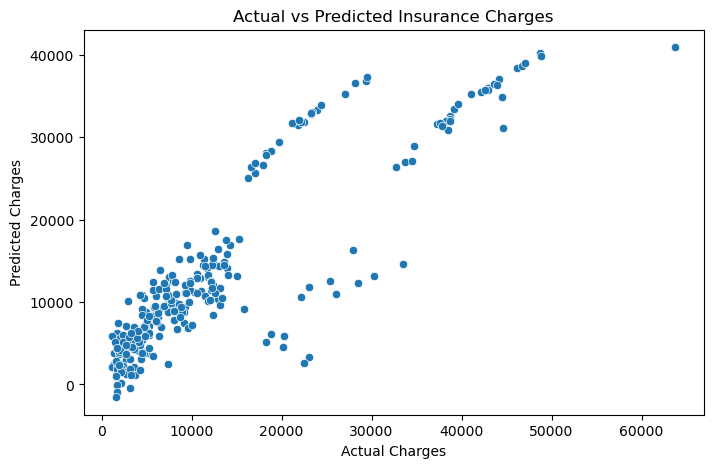

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')

plt.show()


### Linear Regression Model Performance

The linear regression model achieved an **R² score of 0.7836** on the test set, explaining approximately **78.36% of the variation** in insurance charges.

- **Smoking status** was the most influential feature in the model.
- **Age** and **BMI** showed positive relationships with insurance charges.
- The model provides **reasonably good predictions** overall.
- However, residual analysis revealed **systematic patterns** and some **large prediction errors**.
- These findings indicate that the linear model does not fully capture the **complexity of insurance costs**.

Overall, the model performs well as a baseline, but more advanced or nonlinear approaches may improve prediction accuracy.
